# Notebook de experimentación
## Detección adaptativa de carriles

En este notebook hemos reunido la parte de experimentación de nuestro proyecto a partir del trabajo que ya teníamos en **`NooteBook_Pipeline.ipynb`** y de las pruebas que se nos piden en el documento de evaluación.

La idea aquí no ha sido cambiar el algoritmo, sino usar **nuestro código tal como lo tenemos** y medir su comportamiento de una forma ordenada.

### Qué vamos a evaluar
Nos vamos a centrar solo en estas tres métricas:

1. **Tasa de detección de ambas líneas**
2. **Consistencia temporal**
3. **Distancia inter-carril**

### Qué hacemos en este notebook
- cargamos una secuencia de imágenes de **día** y otra de **noche**
- usamos nuestro clasificador de iluminación
- aplicamos nuestro pipeline de **día** y nuestro pipeline de **noche**
- extraemos las rectas detectadas en cada frame
- calculamos únicamente las tres pruebas pedidas

In [1]:
# ==========================================
# 1. IMPORTS
# ==========================================
import os
import cv2
import math
import random
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 6)

## Rutas del dataset

Aquí dejamos las rutas que hemos usado para cargar las bases de datos con las que vamos a hacer las pruebas.

- `RUTA_TUSIMPLE`: secuencia de día
- `RUTA_NOCTURNA`: secuencia de noche
- `RUTA_UDACITY`: ruta opcional por si queremos hacer alguna prueba adicional

Para la memoria nos interesa sobre todo comparar **día** y **noche**, así que el notebook está preparado principalmente para esos dos casos.

In [15]:
# ==========================================
# 2. RUTAS
# ==========================================
RUTA_TUSIMPLE = r"C:\Users\Dani\Desktop\Trabajo PID\BD\BD1\TUSimple\test_set\clips\0530"
RUTA_NOCTURNA = r"C:\Users\hugot\Downloads\BD2\BD2"

In [3]:
# ==========================================
# 3. CARGA DE SECUENCIAS
# ==========================================
def cargar_secuencia_tusimple(ruta_base):
    carpetas_videos = [
        os.path.join(ruta_base, d)
        for d in os.listdir(ruta_base)
        if os.path.isdir(os.path.join(ruta_base, d))
    ]

    if not carpetas_videos:
        print("Error: No se encontraron subcarpetas en TuSimple.")
        return []

    carpeta_elegida = random.choice(carpetas_videos)
    nombre_video = os.path.basename(carpeta_elegida)

    fotogramas = sorted([
        os.path.join(carpeta_elegida, f)
        for f in os.listdir(carpeta_elegida)
        if f.lower().endswith(".jpg") or f.lower().endswith(".png")
    ])

    print(f"TuSimple cargado: clip '{nombre_video}' con {len(fotogramas)} fotogramas.")
    return fotogramas


def cargar_secuencia_bd2_nocturna(ruta_base):
    carpetas_videos = [
        os.path.join(ruta_base, d)
        for d in os.listdir(ruta_base)
        if os.path.isdir(os.path.join(ruta_base, d))
    ]

    if not carpetas_videos:
        print("Error: No se encontraron subcarpetas en BD2.")
        return []

    carpeta_elegida = random.choice(carpetas_videos)
    nombre_video = os.path.basename(carpeta_elegida)

    fotogramas = sorted([
        os.path.join(carpeta_elegida, f)
        for f in os.listdir(carpeta_elegida)
        if f.lower().endswith(".jpg") or f.lower().endswith(".png")
    ])

    print(f"BD2 nocturna cargada: clip '{nombre_video}' con {len(fotogramas)} fotogramas.")
    return fotogramas


def cargar_secuencia_udacity(ruta_base, max_frames=300):
    fotogramas = sorted([
        os.path.join(ruta_base, f)
        for f in os.listdir(ruta_base)
        if f.lower().endswith(".jpg") or f.lower().endswith(".png")
    ])

    if not fotogramas:
        print("Error: No se encontraron imágenes en Udacity.")
        return []

    fotogramas = fotogramas[:max_frames]
    print(f"Udacity cargado: {len(fotogramas)} fotogramas.")
    return fotogramas

In [4]:
# ==========================================
# 4. VISUALIZACIÓN DE APOYO
# ==========================================
def mostrar_muestras(rutas, titulo, n=4):
    if not rutas:
        print(f"No hay datos para {titulo}.")
        return

    n = min(n, len(rutas))
    fig, axs = plt.subplots(1, n, figsize=(5*n, 4))
    if n == 1:
        axs = [axs]

    for ax, ruta in zip(axs, rutas[:n]):
        img = cv2.imread(ruta)
        if img is None:
            ax.set_title("No cargada")
            ax.axis("off")
            continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        ax.set_title(os.path.basename(ruta))
        ax.axis("off")

    fig.suptitle(titulo, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

## Clasificador de iluminación

Esta función la mantenemos prácticamente igual que en nuestro notebook original. Lo que hace es calcular el brillo medio del frame y, a partir de ahí, decidir si lo tratamos como una escena de **día** o de **noche**.

In [5]:
# ==========================================
# 5. CLASIFICADOR DE ILUMINACIÓN
# ==========================================
def evaluar_iluminacion(imagen, umbral=50):
    imagen_gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    brillo_medio = np.mean(imagen_gris)

    if brillo_medio > umbral:
        modo = "DÍA"
    else:
        modo = "NOCHE"

    return imagen_gris, brillo_medio, modo

## Pipelines adaptados para la experimentación

En esta parte hemos adaptado nuestro pipeline para que, además de devolver la imagen con los carriles dibujados, también nos devuelva los parámetros de las rectas detectadas.

### Qué hemos cambiado
Antes nos interesaba sobre todo ver el resultado visual. Ahora, para poder medir las pruebas del seguimiento, necesitamos guardar también:

- `m_izq`, `c_izq`
- `m_der`, `c_der`

Con eso podemos calcular exactamente las tres métricas que nos piden en la experimentación.

In [6]:
# ==========================================
# 6. PIPELINE DE DÍA (ADAPTADO)
# ==========================================
def procesar_dia_experimento(img_bgr):
    alto, ancho = img_bgr.shape[:2]
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Preprocesamiento
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    mask_amarillo = cv2.inRange(hsv, np.array([15, 80, 80]), np.array([35, 255, 255]))
    mask_blanco = cv2.inRange(hsv, np.array([0, 0, 200]), np.array([180, 30, 255]))
    mascara_color = cv2.bitwise_or(mask_amarillo, mask_blanco)
    img_filtrada = cv2.bitwise_and(img_bgr, img_bgr, mask=mascara_color)
    img_blur = cv2.GaussianBlur(cv2.cvtColor(img_filtrada, cv2.COLOR_BGR2GRAY), (5, 5), 0)

    # Canny + ROI
    img_canny = cv2.Canny(img_blur, 50, 150)
    poligono = np.array([[
        (0, alto),
        (ancho, alto),
        (int(ancho * 0.75), int(alto * 0.6)),
        (int(ancho * 0.25), int(alto * 0.6))
    ]])
    mask_roi = np.zeros_like(img_canny)
    cv2.fillPoly(mask_roi, poligono, 255)
    img_roi = cv2.bitwise_and(img_canny, mask_roi)

    # Hough estándar
    lineas = cv2.HoughLines(img_roi, rho=1, theta=np.pi/180, threshold=80)

    p_izq, c_izq = [], []
    p_der, c_der = [], []

    if lineas is not None:
        for linea in lineas:
            rho, theta = linea[0]

            if math.sin(theta) == 0:
                continue

            slope = -math.cos(theta) / math.sin(theta)
            intercept = rho / math.sin(theta)

            if slope < -0.5:
                p_izq.append(slope)
                c_izq.append(intercept)
            elif slope > 0.5:
                p_der.append(slope)
                c_der.append(intercept)

    m_izq = float(np.mean(p_izq)) if len(p_izq) > 0 else None
    b_izq = float(np.mean(c_izq)) if len(c_izq) > 0 else None
    m_der = float(np.mean(p_der)) if len(p_der) > 0 else None
    b_der = float(np.mean(c_der)) if len(c_der) > 0 else None

    img_out = np.copy(img_rgb)
    y_min, y_max = int(alto * 0.6), alto

    if m_izq is not None and b_izq is not None:
        x1 = int((y_max - b_izq) / m_izq)
        x2 = int((y_min - b_izq) / m_izq)
        cv2.line(img_out, (x1, y_max), (x2, y_min), (0, 255, 0), 8)

    if m_der is not None and b_der is not None:
        x1 = int((y_max - b_der) / m_der)
        x2 = int((y_min - b_der) / m_der)
        cv2.line(img_out, (x1, y_max), (x2, y_min), (0, 255, 0), 8)

    return {
        "imagen": img_out,
        "m_izq": m_izq,
        "c_izq": b_izq,
        "m_der": m_der,
        "c_der": b_der
    }

In [7]:
# ==========================================
# 7. PIPELINE DE NOCHE (ADAPTADO)
# ==========================================
def procesar_noche_experimento(img_bgr, y_average):
    alto, ancho = img_bgr.shape[:2]
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Gamma adaptativo
    gamma_final = 0.7 - (-0.3 / math.log10(max(y_average, 1e-6)))
    tabla = np.array([
        ((i / 255.0) ** (1.0 / gamma_final)) * 255
        for i in np.arange(0, 256)
    ]).astype("uint8")
    img_gamma = cv2.LUT(img_bgr, tabla)

    # HSV estricto
    hsv = cv2.cvtColor(img_gamma, cv2.COLOR_BGR2HSV)
    mask_blanco = cv2.inRange(hsv, np.array([0, 0, 180]), np.array([180, 30, 255]))
    mask_amarillo = cv2.inRange(hsv, np.array([15, 80, 80]), np.array([35, 255, 255]))
    mask_total = cv2.bitwise_or(mask_blanco, mask_amarillo)

    # ROI
    horizonte = 0.70
    poligono = np.array([[
        (0, alto),
        (ancho, alto),
        (int(ancho * 0.75), int(alto * horizonte)),
        (int(ancho * 0.25), int(alto * horizonte))
    ]])
    mask_roi = np.zeros_like(mask_total)
    cv2.fillPoly(mask_roi, poligono, 255)
    img_roi = cv2.bitwise_and(mask_total, mask_roi)

    # Hough probabilístico
    lineas = cv2.HoughLinesP(img_roi, 1, np.pi/180, 20, minLineLength=15, maxLineGap=200)
    cand_izq, cand_der = [], []
    centro_x = ancho / 2

    if lineas is not None:
        for linea in lineas:
            x1, y1, x2, y2 = linea[0]
            if x1 == x2:
                continue

            m = (y2 - y1) / (x2 - x1)
            c = y1 - m * x1
            theta = abs(math.atan(m))
            d = abs(((x1 + x2) / 2) - centro_x)

            if math.radians(20) < theta < math.radians(80):
                if m < 0:
                    cand_izq.append({"d": d, "m": m, "c": c})
                else:
                    cand_der.append({"d": d, "m": m, "c": c})

    mejor_izq = min(cand_izq, key=lambda x: x["d"]) if len(cand_izq) > 0 else None
    mejor_der = min(cand_der, key=lambda x: x["d"]) if len(cand_der) > 0 else None

    m_izq = mejor_izq["m"] if mejor_izq is not None else None
    b_izq = mejor_izq["c"] if mejor_izq is not None else None
    m_der = mejor_der["m"] if mejor_der is not None else None
    b_der = mejor_der["c"] if mejor_der is not None else None

    img_out = np.copy(img_rgb)
    y_min, y_max = int(alto * horizonte), alto

    if m_izq is not None and b_izq is not None:
        x1 = int((y_max - b_izq) / m_izq)
        x2 = int((y_min - b_izq) / m_izq)
        cv2.line(img_out, (x1, y_max), (x2, y_min), (0, 255, 0), 8)

    if m_der is not None and b_der is not None:
        x1 = int((y_max - b_der) / m_der)
        x2 = int((y_min - b_der) / m_der)
        cv2.line(img_out, (x1, y_max), (x2, y_min), (0, 255, 0), 8)

    return {
        "imagen": img_out,
        "m_izq": m_izq,
        "c_izq": b_izq,
        "m_der": m_der,
        "c_der": b_der
    }

## Clase de evaluación

Aquí hemos implementado una clase sencilla que se encarga de registrar frame a frame lo que detecta el algoritmo.

Nos hemos ceñido a las **tres pruebas exactas** del documento:

- tasa de detección de ambas líneas
- consistencia temporal
- distancia inter-carril

La idea es que toda la evaluación salga de aquí y que no metamos métricas extra que luego no vayamos a comentar en la memoria.

In [8]:
# ==========================================
# 8. EVALUADOR EXACTO DE LAS 3 PRUEBAS
# ==========================================
class EvaluadorCarriles:
    def __init__(self, umbral_consistencia=0.10, y_base=720):
        self.total_frames = 0
        self.frames_con_ambas_lineas = 0
        self.frames_consistentes = 0
        self.historial_distancias = []

        self.umbral_consistencia = umbral_consistencia
        self.ultima_izq = None
        self.ultima_der = None
        self.y_base = y_base

    def registrar_frame(self, m_izq, c_izq, m_der, c_der):
        self.total_frames += 1
        deteccion_actual_completa = False

        # 1) Detección de ambas líneas
        if m_izq is not None and m_der is not None and c_izq is not None and c_der is not None:
            self.frames_con_ambas_lineas += 1
            deteccion_actual_completa = True

            # 2) Distancia inter-carril
            x_izq = (self.y_base - c_izq) / m_izq
            x_der = (self.y_base - c_der) / m_der
            distancia = abs(x_der - x_izq)
            self.historial_distancias.append(distancia)

        # 3) Consistencia temporal
        if deteccion_actual_completa and self.ultima_izq is not None and self.ultima_der is not None:
            if self.ultima_izq[0] != 0 and self.ultima_der[0] != 0:
                cambio_m_izq = abs(m_izq - self.ultima_izq[0]) / abs(self.ultima_izq[0])
                cambio_m_der = abs(m_der - self.ultima_der[0]) / abs(self.ultima_der[0])

                if cambio_m_izq < self.umbral_consistencia and cambio_m_der < self.umbral_consistencia:
                    self.frames_consistentes += 1

        if m_izq is not None and c_izq is not None:
            self.ultima_izq = (m_izq, c_izq)
        if m_der is not None and c_der is not None:
            self.ultima_der = (m_der, c_der)

    def obtener_informe(self, imprimir=True):
        tasa_deteccion = (self.frames_con_ambas_lineas / self.total_frames) if self.total_frames > 0 else 0
        consistencia = (self.frames_consistentes / self.total_frames) if self.total_frames > 0 else 0
        distancia_media = float(np.mean(self.historial_distancias)) if self.historial_distancias else 0.0

        informe = {
            "total_frames": self.total_frames,
            "tasa_deteccion": tasa_deteccion,
            "consistencia_temporal": consistencia,
            "distancia_media": distancia_media,
        }

        if imprimir:
            print("--- INFORME DE RENDIMIENTO ---")
            print(f"Total Frames Procesados: {self.total_frames}")
            print(f"1. Tasa de Detección (Ambas líneas): {tasa_deteccion:.2%}")
            print(f"2. Consistencia Temporal: {consistencia:.2f}")
            print(f"3. Distancia Media (Lane Width): {distancia_media:.2f} px")

        return informe

## Evaluación de una secuencia

En esta función recorremos una secuencia de frames y vamos aplicando el procesamiento correspondiente en cada caso.

- si el brillo supera el umbral, se usa el modo día
- si no, se usa el modo noche

De todas formas, para que la comparación sea más limpia, también dejamos la opción de **forzar el modo** cuando sabemos que una secuencia es completamente diurna o completamente nocturna.

In [9]:
# ==========================================
# 9. EVALUACIÓN DE SECUENCIA
# ==========================================
def evaluar_secuencia(rutas_frames, modo_forzado=None, umbral_luz=50, max_frames=None, frame_stride=1, mostrar_cada=None):
    if not rutas_frames:
        print("No hay frames para evaluar.")
        return None

    primer_frame = cv2.imread(rutas_frames[0])
    alto = primer_frame.shape[0]
    evaluador = EvaluadorCarriles(umbral_consistencia=0.10, y_base=alto - 1)

    procesados = 0

    for i, ruta in enumerate(rutas_frames):
        if i % frame_stride != 0:
            continue

        frame = cv2.imread(ruta)
        if frame is None:
            continue

        _, brillo, modo_estimado = evaluar_iluminacion(frame, umbral=umbral_luz)
        modo = modo_forzado if modo_forzado is not None else modo_estimado

        if modo == "DÍA":
            resultado = procesar_dia_experimento(frame)
        else:
            resultado = procesar_noche_experimento(frame, brillo)

        evaluador.registrar_frame(
            resultado["m_izq"],
            resultado["c_izq"],
            resultado["m_der"],
            resultado["c_der"]
        )

        if mostrar_cada is not None and procesados % mostrar_cada == 0:
            print(f"[{procesados}] modo={modo} brillo={brillo:.2f} "
                  f"m_izq={resultado['m_izq']} m_der={resultado['m_der']}")

        procesados += 1

        if max_frames is not None and procesados >= max_frames:
            break

    return evaluador.obtener_informe(imprimir=True)

## Carga de datos para la experimentación

En esta parte cargamos directamente una secuencia de **día** y una secuencia de **noche**, que son las dos que vamos a comparar en el análisis final.

In [12]:
# ==========================================
# 10. CARGA DE DATOS PARA EXPERIMENTACIÓN
# ==========================================
#frames_dia = cargar_secuencia_tusimple(RUTA_TUSIMPLE)
frames_noche = cargar_secuencia_bd2_nocturna(RUTA_NOCTURNA)

#print(f"Frames día: {len(frames_dia)}")
print(f"Frames noche: {len(frames_noche)}")

BD2 nocturna cargada: clip 'clip_043' con 20 fotogramas.
Frames noche: 20


In [ ]:
# Muestras visuales
#mostrar_muestras(frames_dia, "Muestras de día", n=4)
mostrar_muestras(frames_noche, "Muestras de noche", n=4)

## Comprobación visual del pipeline

Antes de ejecutar toda la experimentación, nos viene bien comprobar visualmente que el pipeline está detectando los carriles de forma razonable tanto en un ejemplo de día como en uno de noche.

In [ ]:
# ==========================================
# 11. PRUEBA VISUAL DE UN FRAME DE DÍA
# ==========================================
if frames_dia:
    img = cv2.imread(frames_dia[0])
    salida = procesar_dia_experimento(img)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original día")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(salida["imagen"])
    plt.title("Resultado día")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    print("Parámetros detectados:")
    print("m_izq =", salida["m_izq"])
    print("c_izq =", salida["c_izq"])
    print("m_der =", salida["m_der"])
    print("c_der =", salida["c_der"])

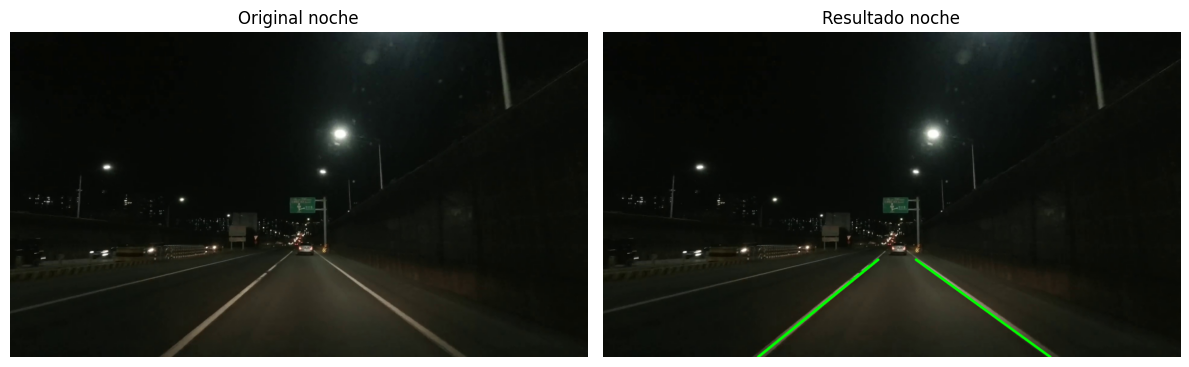

Brillo medio = 19.21171633873457
m_izq = -0.8127490039840638
c_izq = 1498.8884462151395
m_der = 0.7262569832402235
c_der = 0.7318435754190205


In [13]:
# ==========================================
# 12. PRUEBA VISUAL DE UN FRAME DE NOCHE
# ==========================================
if frames_noche:
    img = cv2.imread(frames_noche[0])
    _, brillo, _ = evaluar_iluminacion(img)
    salida = procesar_noche_experimento(img, brillo)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original noche")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(salida["imagen"])
    plt.title("Resultado noche")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    print("Brillo medio =", brillo)
    print("m_izq =", salida["m_izq"])
    print("c_izq =", salida["c_izq"])
    print("m_der =", salida["m_der"])
    print("c_der =", salida["c_der"])

## Ejecución de la experimentación

Estas dos celdas son las que generan los informes que luego vamos a usar en la memoria:

- informe de día
- informe de noche

A partir de esos dos resultados podremos comparar cómo se comporta el sistema en condiciones distintas de iluminación.

In [ ]:
# ==========================================
# 13. EXPERIMENTACIÓN EN DÍA
# ==========================================
informe_dia = evaluar_secuencia(
    frames_dia,
    modo_forzado="DÍA",
    umbral_luz=50,
    max_frames=300,
    frame_stride=1,
    mostrar_cada=None
)

In [14]:
# ==========================================
# 14. EXPERIMENTACIÓN EN NOCHE
# ==========================================
informe_noche = evaluar_secuencia(
    frames_noche,
    modo_forzado="NOCHE",
    umbral_luz=50,
    max_frames=300,
    frame_stride=1,
    mostrar_cada=None
)

--- INFORME DE RENDIMIENTO ---
Total Frames Procesados: 20
1. Tasa de Detección (Ambas líneas): 80.00%
2. Consistencia Temporal: 0.75
3. Distancia Media (Lane Width): 947.88 px


## Comparación final

En la parte final comparamos únicamente las **tres métricas pedidas**. Así dejamos la experimentación cerrada y alineada con lo que se pide en el proyecto.

In [ ]:
# ==========================================
# 15. COMPARACIÓN DÍA / NOCHE
# ==========================================
def comparar_informes(informe_dia, informe_noche):
    print("=== COMPARATIVA DÍA / NOCHE ===")
    print(f"Tasa de detección día   : {informe_dia['tasa_deteccion']:.2%}")
    print(f"Tasa de detección noche : {informe_noche['tasa_deteccion']:.2%}")
    print()

    print(f"Consistencia día   : {informe_dia['consistencia_temporal']:.2f}")
    print(f"Consistencia noche : {informe_noche['consistencia_temporal']:.2f}")
    print()

    print(f"Distancia media día   : {informe_dia['distancia_media']:.2f} px")
    print(f"Distancia media noche : {informe_noche['distancia_media']:.2f} px")

comparar_informes(informe_dia, informe_noche)

In [ ]:
# ==========================================
# 16. GRÁFICA DE COMPARACIÓN
# ==========================================
def graficar_comparacion(informe_dia, informe_noche):
    metricas = ["tasa_deteccion", "consistencia_temporal", "distancia_media"]
    nombres = ["Tasa detección", "Consistencia", "Distancia media"]

    valores_dia = [informe_dia[m] for m in metricas]
    valores_noche = [informe_noche[m] for m in metricas]

    x = np.arange(len(metricas))
    width = 0.35

    plt.figure(figsize=(10, 5))
    plt.bar(x - width/2, valores_dia, width, label="Día")
    plt.bar(x + width/2, valores_noche, width, label="Noche")
    plt.xticks(x, nombres)
    plt.title("Comparación de métricas")
    plt.legend()
    plt.tight_layout()
    plt.show()

graficar_comparacion(informe_dia, informe_noche)

## Resumen


En esta fase hemos evaluado nuestro sistema utilizando dos conjuntos de datos distintos: una secuencia de día procedente de TuSimple y una secuencia de noche obtenida de la base de datos nocturna. En cada fotograma hemos aplicado el pipeline correspondiente según las condiciones de iluminación. Para las escenas diurnas hemos usado nuestro método basado en filtrado HSV, detector de Canny, región de interés y transformada de Hough estándar. Para las escenas nocturnas hemos utilizado la versión adaptada con corrección gamma, filtrado HSV más restrictivo, región de interés y transformada de Hough probabilística.

A la hora de hacer la experimentación nos hemos limitado a las tres pruebas indicadas en el documento de referencia. En primer lugar, hemos calculado la tasa de detección de ambas líneas, es decir, el porcentaje de fotogramas en los que el algoritmo detecta simultáneamente el carril izquierdo y el derecho. En segundo lugar, hemos medido la consistencia temporal, que nos sirve para comprobar si la detección se mantiene estable entre fotogramas consecutivos o si, por el contrario, da saltos bruscos. Por último, hemos calculado la distancia inter-carril en la base de la imagen para ver si el ancho detectado del carril se mantiene razonablemente constante.

Con estos resultados podemos comparar de una forma bastante clara cómo responde nuestro sistema en condiciones de día y de noche. Una tasa de detección alta significa que el algoritmo localiza bien ambos límites del carril. Una consistencia temporal elevada indica que las líneas se mantienen estables a lo largo de la secuencia. Por último, una distancia inter-carril aproximadamente constante nos da una señal de que la geometría detectada es coherente.